In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
#Load the data
df=pd.read_csv("smartcart_customers.csv")

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [9]:
#Handle missing value
df['Income']=df['Income'].fillna(df['Income'].median())

In [10]:
df.isnull().sum() #no null value in the data 

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering 

In [11]:
#Replace age with data of birth
df["Age"]=2026-df['Year_Birth']

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [13]:
#Changing the Dt_customer to tenure days
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]= (reference_date - df["Dt_Customer"]).dt.days

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [15]:
#Total Spending

df["Total_Spending"]= df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"] +df["MntSweetProducts"] +df["MntGoldProds"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [17]:
#Total childrens
df["Total_Childrens"]=df["Kidhome"]+df["Teenhome"]

In [18]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [19]:
#Education
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [20]:
#Making only 3 usefull columns
#Undergrad, Graduate, Postgraduate

df["Education"]=df["Education"].replace({
    "Basic" :"Undergraduate","2n Cycle" :"Undergraduate",
    "Graduation" :"Graduate",
    "Master" : "Postgraduate", "PhD": "Postgraduate"
    
})

In [21]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [22]:
#Marital-Status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [23]:
df["Living_With"]=df["Marital_Status"].replace({
    "Married" :"Partner","Together" :"Partner",
    "Single" :"Alone","Divorced":"Alone","Widow": "Alone","Absurd":"Alone","YOLO" : "Alone",
})

In [24]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [ ]:
#Dropping unnecessary columns
col=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
Spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts" ,"MntSweetProducts" ,"MntGoldProds"]


In [26]:
df_cleaned = df.drop(columns=col + Spending_cols)

In [27]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [28]:
df_cleaned.shape

(2240, 15)

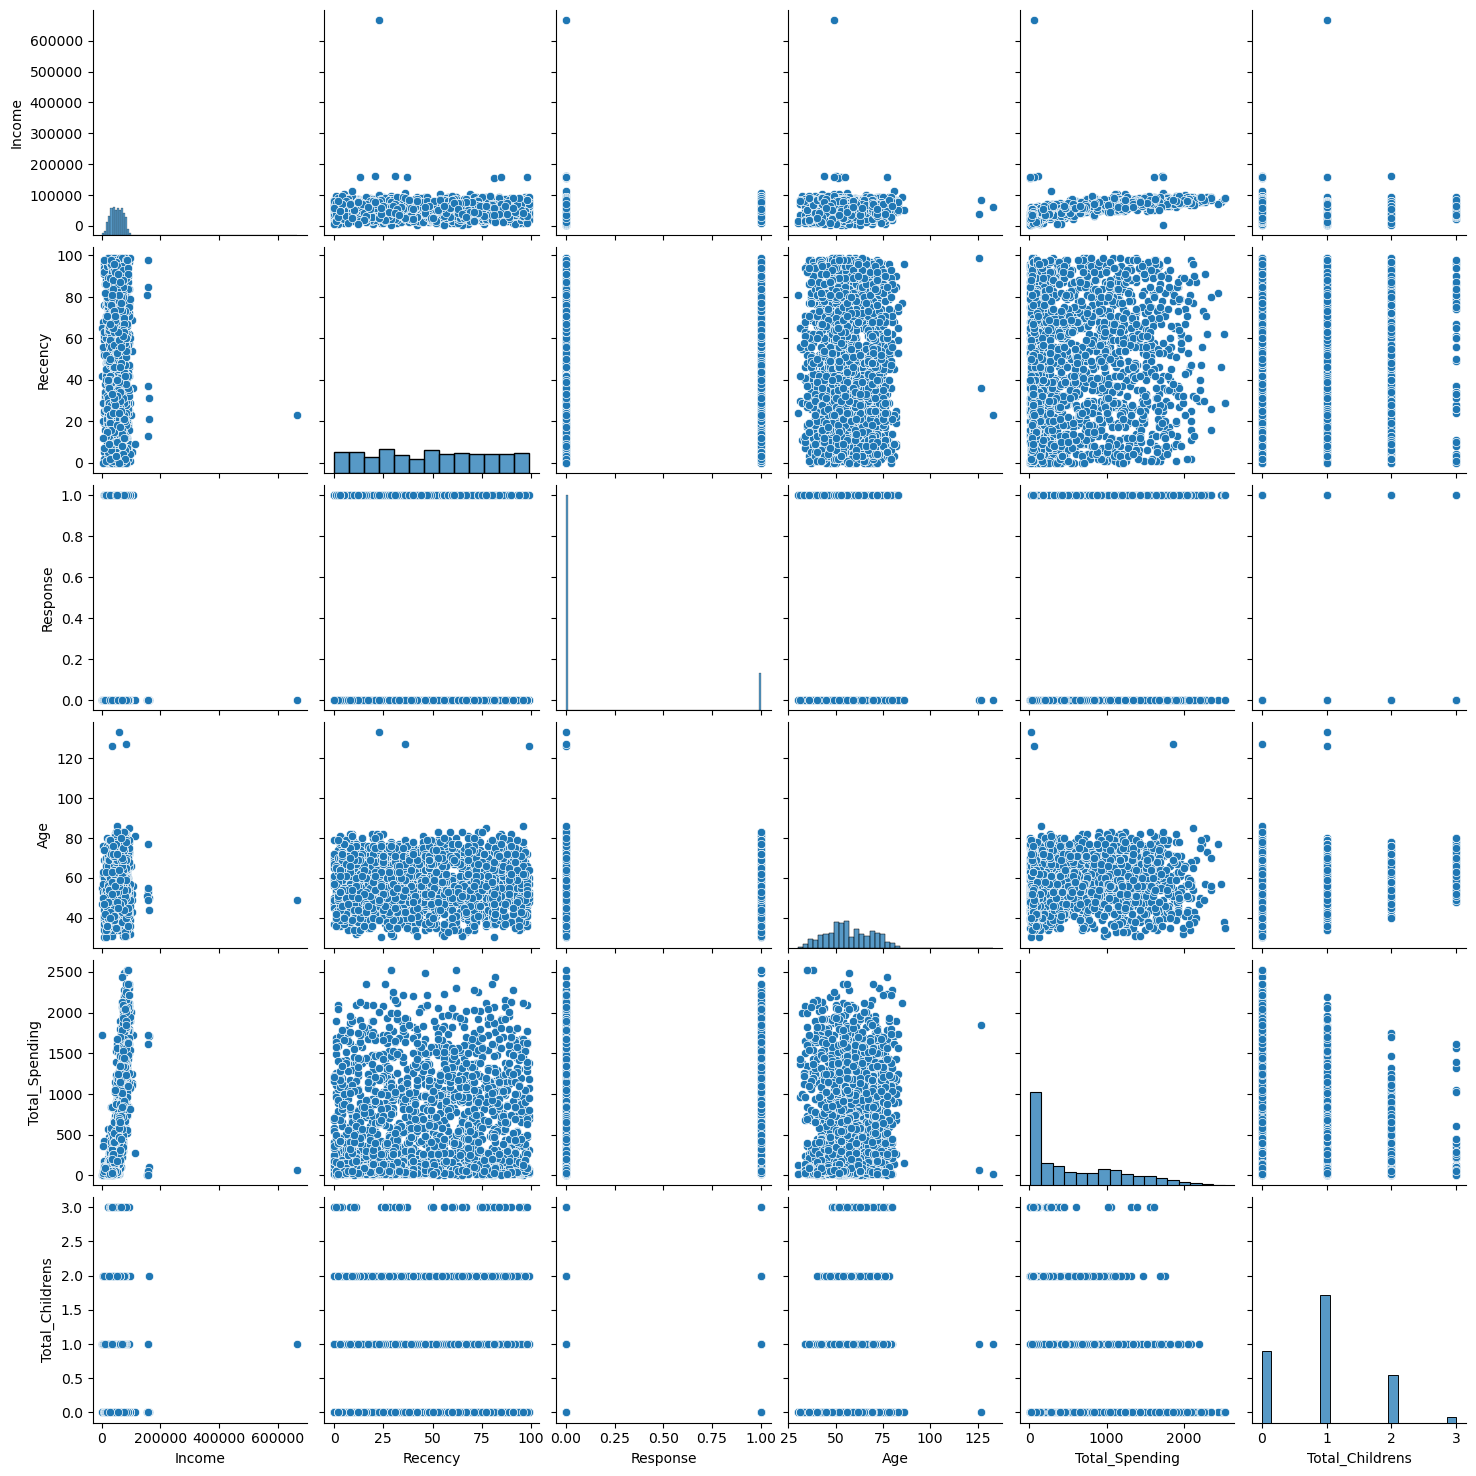

In [29]:
#Outliers Detection
cols=["Income","Recency","Response","Age","Total_Spending","Total_Childrens"]

#Pair plot for relative ploting
sns.pairplot(df_cleaned[cols])

In [30]:
#Remove Outliers
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]

In [31]:
#Correlation with heatmap
corr=df_cleaned.corr(numeric_only=True)


<Axes: >

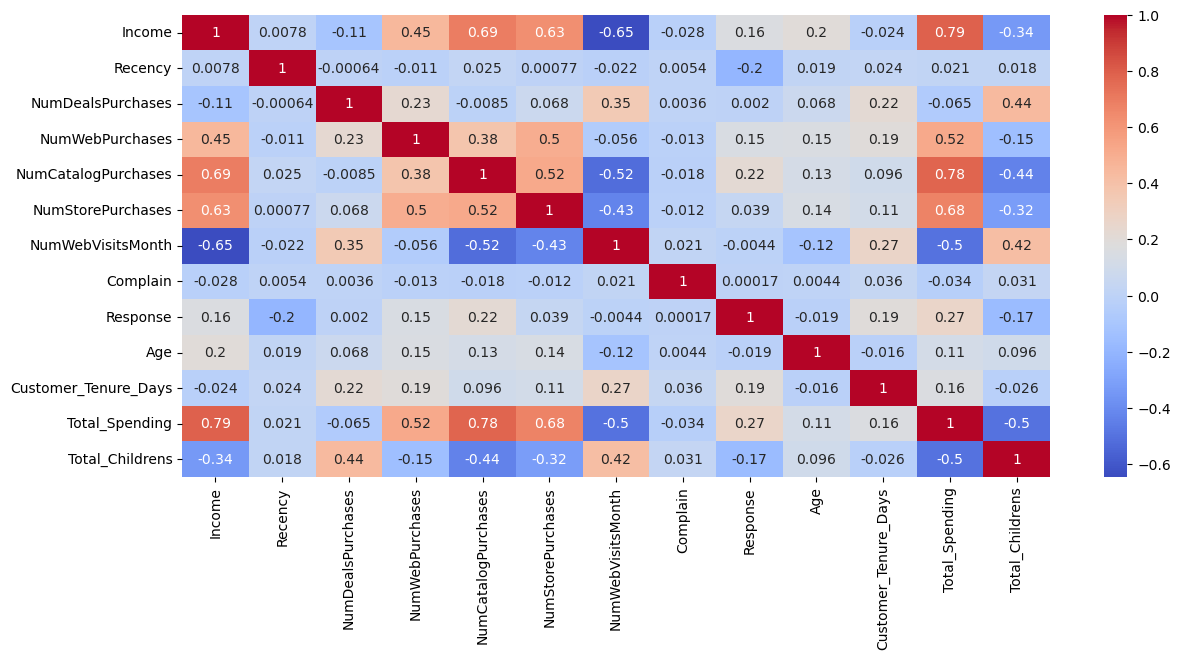

In [32]:
plt.figure(figsize=(14,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"

)

# Encoding

In [33]:
from sklearn.preprocessing import OneHotEncoder

In [34]:
ohe = OneHotEncoder()

cat_cols=["Education","Living_With"]

enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [35]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [36]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [37]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [38]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
X=df_encoded

In [41]:
scalar=StandardScaler()

X_scaled=scalar.fit_transform(X)

In [42]:
#PCA to reduce dimensions
#2D

from sklearn.decomposition import PCA


In [43]:
pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D projection')

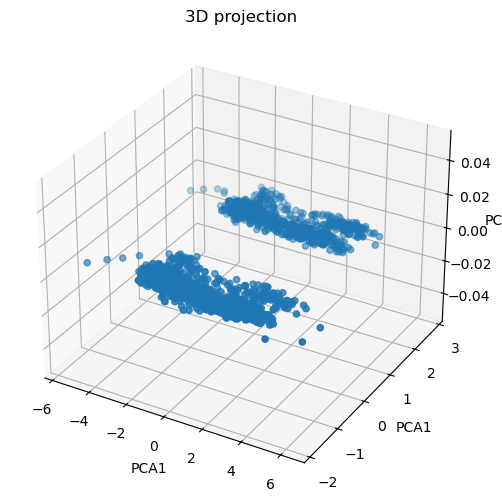

In [ ]:
#Plot
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

# Analyze K-value 
# 1. Elbow Method

In [48]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss= []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


In [50]:
knee=KneeLocator(range(1,11),wcss, curve="convex", direction="decreasing")
optimal_k =knee.elbow

In [51]:
print(optimal_k)

4


Text(0, 0.5, 'WCSS')

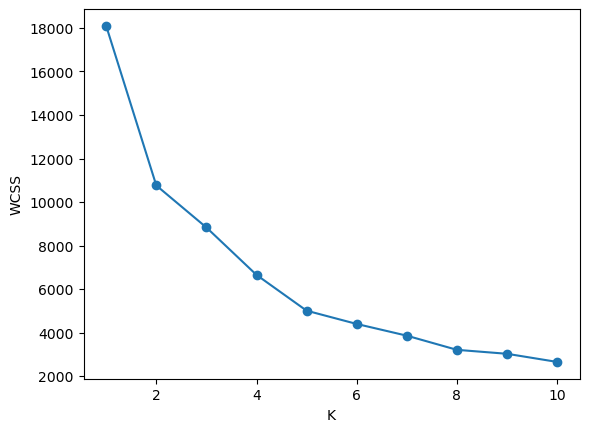

In [52]:
#plot

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

# 2.Silhouette Score

In [53]:
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca, labels)
    scores.append(score)

    

Text(0, 0.5, 'Silhouette Score')

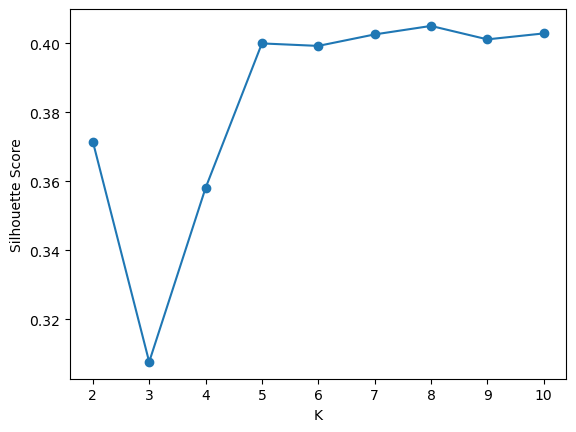

In [58]:
#plot
plt.plot(range(2,11),scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")

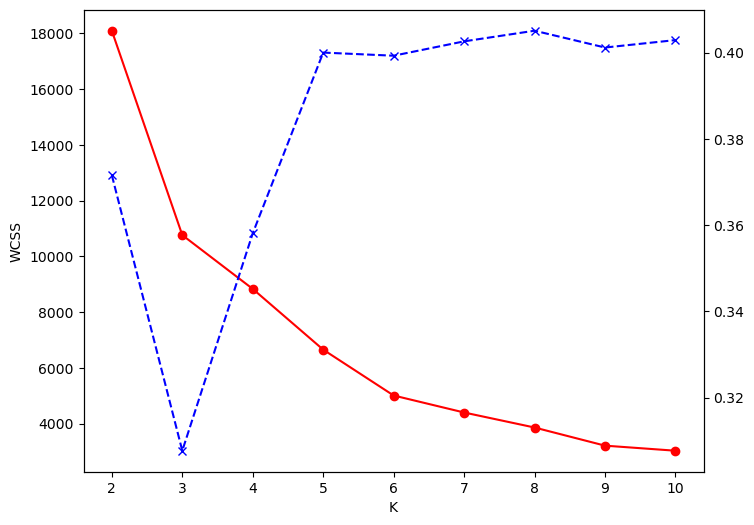

In [64]:
#combine plot

k_range=range(2,11)

fig, ax1= plt.subplots(figsize=(8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color="red")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color="blue",linestyle="--")


# Clustering


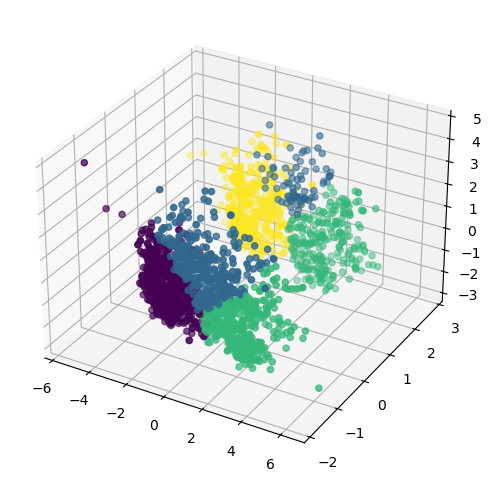

In [65]:
#K_Means

kmeans=KMeans(n_clusters=4, random_state=42)
labels=kmeans.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)


In [66]:
#Agglormerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [69]:
agg_clt=AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg=agg_clt.fit_predict(X_pca)

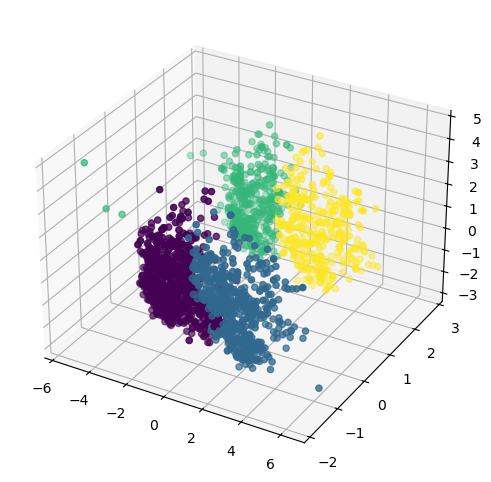

In [70]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)


In [71]:
#Characterization of clusters

X["labels"]=labels_agg

In [72]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrens,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='labels', ylabel='count'>

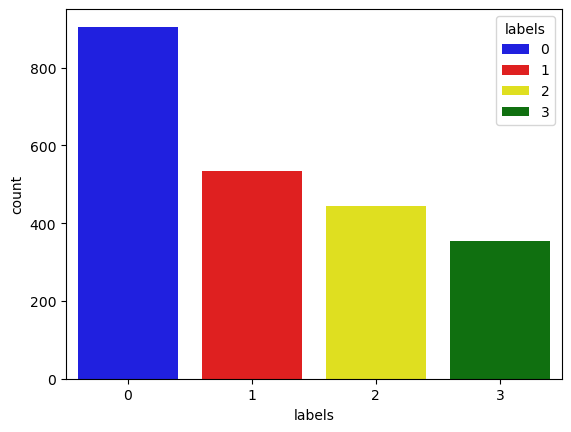

In [74]:
pal = ["blue","red","yellow","green"]
sns.countplot(x=X["labels"],palette=pal, hue=X["labels"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

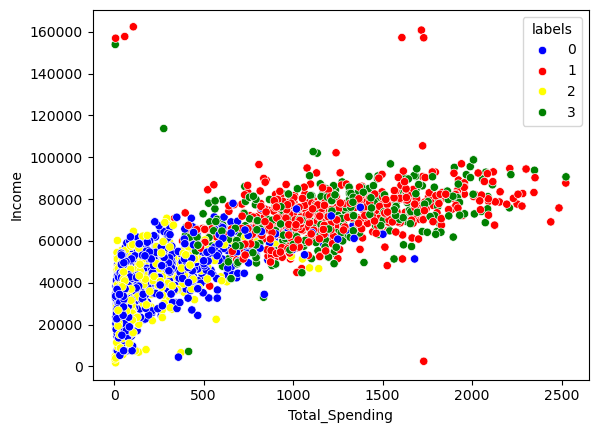

In [76]:
#Income and Spending Patterns

sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["labels"],palette=pal)


In [79]:
#Cluster Summary

cluster_summary=X.groupby("labels").mean()
print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
labels                                                                
0       39680.580110  48.914917           2.594475         3.153591   
1       72808.445693  49.202247           1.958801         5.687266   
2       36960.143018  48.319820           2.594595         2.713964   
3       70722.681303  50.504249           1.855524         5.790368   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
labels                                                                        
0                  0.969061           4.143646           6.307182  0.011050   
1                  5.498127           8.659176           3.580524  0.005618   
2                  0.837838           3.623874           6.659910  0.011261   
3                  5.014164           8.430595           3.728045  0.005666   

        Response        Age  Customer_Tenure_Days  Total_Spending  \
labels                       